In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df=pd.read_csv(r"C:\Users\Aantriksh\Desktop\AIML_Lab\datasets\city_day.csv")
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [3]:
df.dropna(inplace = True)

In [4]:
# For clustering, we need to select the features that are relevant for our analysis.
df.drop(['City' , 'Date' , 'AQI_Bucket'] , axis =1 , inplace = True)
# we drop the non-numeric columns and the target variable 'AQI_Bucket'.

DBSCAN_Clusters
-1     4588
 0     1137
 7      106
 10      55
 12      50
 11      21
 15      17
 39      16
 8       14
 29      14
 9       13
 13      11
 24      11
 1       11
 6       10
 21      10
 16      10
 26       8
 22       8
 19       8
 5        8
 32       8
 35       7
 30       7
 31       7
 28       7
 17       6
 33       6
 36       6
 34       5
 4        5
 3        5
 20       5
 38       5
 23       5
 18       5
 25       5
 27       5
 2        4
 37       4
 14       3
Name: count, dtype: int64


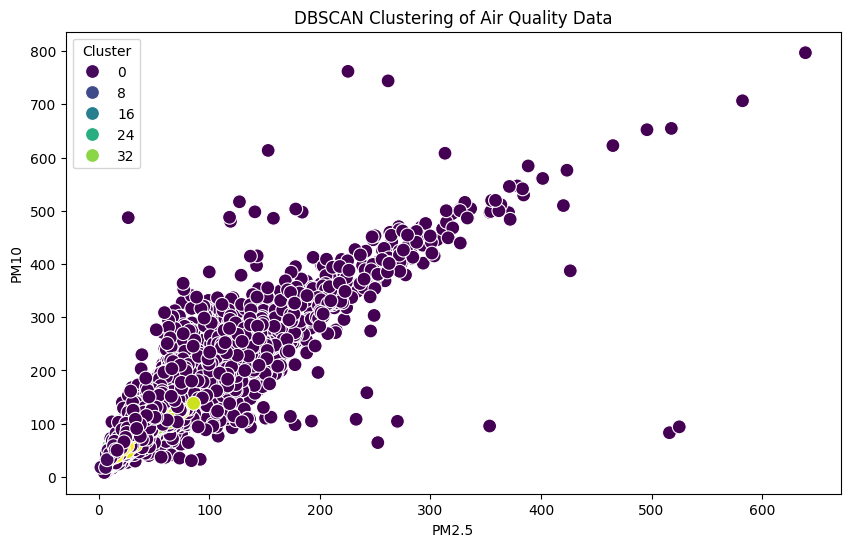

In [ ]:
# Scale 
scaler=StandardScaler()
df_scaled=scaler.fit_transform(df)
# Apply DBSCAN
dbscan=DBSCAN(eps=0.5, min_samples=5) # Default eps=0.5, min_samples=5
# Note: Fitting depends on 'scaled' being defined correctly
# clusters = dbscan.fit_predict(scaled)
clusters = dbscan.fit_predict(df_scaled)
df['DBSCAN_Clusters'] = clusters

print(df['DBSCAN_Clusters'].value_counts())
# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['PM2.5'], y=df['PM10'], hue=df['DBSCAN_Clusters'], palette='viridis', s=100)
plt.title('DBSCAN Clustering of Air Quality Data')
plt.xlabel('PM2.5')
plt.ylabel('PM10')
plt.legend(title='Cluster')
plt.show()

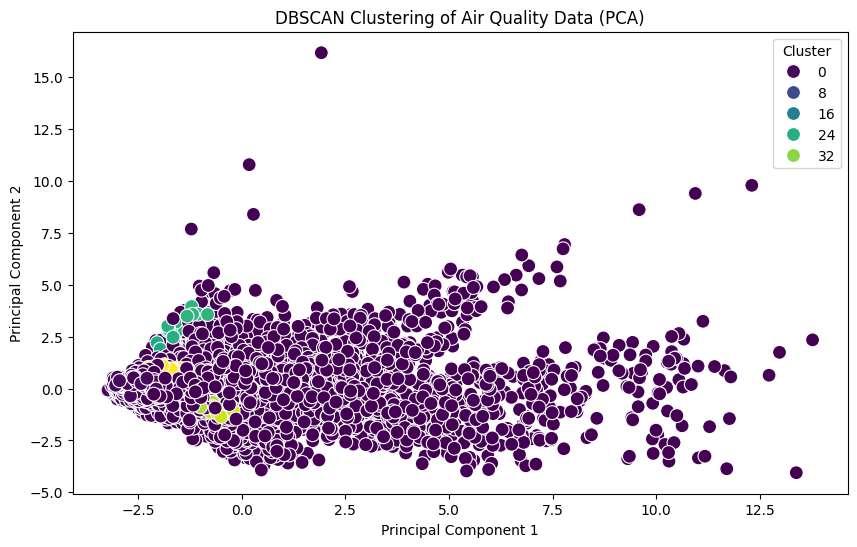

In [7]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])
df_pca['DBSCAN_Clusters'] = clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'], hue=df_pca['DBSCAN_Clusters'], palette='viridis', s=100)
plt.title('DBSCAN Clustering of Air Quality Data (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

                     PM2.5        PM10         NO        NO2        NOx  \
DBSCAN_Clusters                                                           
-1               72.794603  144.113389  20.706833  36.252127  38.335800   
 0               27.415629   61.071416   4.865444  19.136675  13.857282   
 1               37.300909   87.740909   1.407273  18.920000  11.220909   
 2               13.775000   39.707500   2.760000  24.710000  15.447500   
 3               58.490000   98.772000   2.584000  14.232000  10.554000   
 4               80.144000  113.786000   1.968000  14.220000   9.182000   
 5               52.188750  150.307500  15.845000  10.728750  37.123750   
 6               62.192000  120.820000  12.319000   8.567000  20.885000   
 7               31.159528   67.081698  15.009434  11.036321  24.401604   
 8               30.931429   64.160714  21.619286  16.304286  31.209286   
 9               52.549231  111.204615  12.996923   5.433846  13.286154   
 10              15.50545

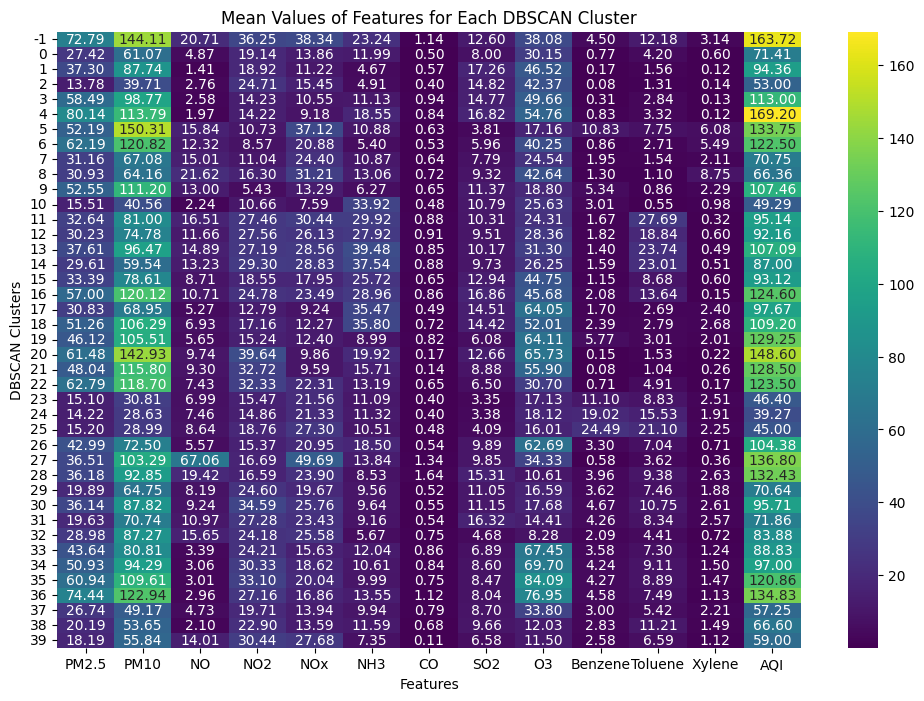

In [8]:
# Now we can analyze the clusters. For example, we can calculate the mean of each feature for each cluster.
cluster_means = df.groupby('DBSCAN_Clusters').mean()
print(cluster_means)
# This will give us an idea of the characteristics of each cluster.
# We can also visualize the mean values of each feature for each cluster using a heatmap.
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_means, annot=True, cmap='viridis', fmt='.2f')
plt.title('Mean Values of Features for Each DBSCAN Cluster')
plt.xlabel('Features')
plt.ylabel('DBSCAN Clusters')
plt.show()